In [9]:
# Install required packages including LangChain, LangGraph, Groq, and PDF processing libraries.
%pip install -q requests==2.32.4 --force-reinstall --no-deps
%pip install -qU langchain-groq langchain-community langgraph pytesseract pypdf pdf2image
!apt-get install -y -q poppler-utils tesseract-ocr

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
Reading package lists...
Building dependency tree...
Reading state information...
tesseract-ocr is already the newest version (4.1.1-2.1build1).
poppler-utils is already the newest version (22.02.0-2ubuntu0.12).
0 upgraded, 0 newly installed, 0 to remove and 5 not upgraded.


Initialize the environment variable for GroQ and Langsmith tracing

In [10]:
# Set up API keys and LangSmith tracing environment variables from Colab secrets.
import os
from google.colab import userdata

os.environ["GROQ_API_KEY"]        = userdata.get("GROQ_API_KEY")
os.environ["LANGSMITH_API_KEY"]   = userdata.get("LANGSMITH_API_KEY")
os.environ["LANGSMITH_TRACING"]   = "true"
os.environ["LANGSMITH_ENDPOINT"]  = "https://api.smith.langchain.com"
os.environ["LANGSMITH_PROJECT"]   = "Praveen Capstone Project"

In [11]:
# Import all required libraries for agents, PDF processing, state management, and graph construction.
import json
import sqlite3
import shutil
import sys
from datetime import datetime
from pathlib import Path
from typing import List, Optional

import pytesseract
from pdf2image import convert_from_path
from IPython.display import Image, display

from langchain_community.document_loaders import PyPDFLoader
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_groq import ChatGroq
from langgraph.graph import END, StateGraph
from langchain.agents import create_agent
from typing_extensions import TypedDict
from langchain.tools import tool

In [12]:
# Define the AgentState TypedDict that holds all shared state fields across the multi-agent workflow.
class AgentState(TypedDict):
    file_path:          str
    file_name:          Optional[str]
    classification:     Optional[str]
    confidence_score:   Optional[str]
    reason:             Optional[str]
    date_received:      Optional[str]
    extraction_details: Optional[dict]
    workflow_step:      Optional[str]
    next_agent:         Optional[str]
    human_decision:     Optional[str]
    audit_log:          List[str]
    messages:           List[str]
    final_message:      Optional[str]

In [13]:
# Initialize the Groq LLM (Qwen 32B) used by manager and classification agents.
llm = ChatGroq(
    model="qwen/qwen3-32b",
    temperature=0,
    reasoning_format="parsed",
    max_retries=2
)

In [14]:
# Define the manager agent's system prompt with top-to-bottom routing rules.
MANAGER_PROMPT = SystemMessage(content="""You are a workflow manager. Decide what to do next with a document.
Evaluate rules TOP TO BOTTOM and stop at the FIRST match.

1. workflow_step is "audit_log"                               → end
2. workflow_step is "database_store" or "archived"            → audit_agent
3. classification is missing or null                          → classification_agent
4. classification is "Cease" or "Irrelevant"                  → database_agent
5. classification is "Uncertain"                              → hitl_agent

Reply ONLY with this JSON, nothing else:
{"next_agent": "classification_agent | database_agent | audit_agent | hitl_agent | end", "reason": "one line explanation"}
""")

In [15]:
# Define the classification agent's system prompt with instructions for C&D document detection.
CLASSIFY_PROMPT = SystemMessage(content='''You are a legal document classification assistant. Your sole responsibility is to determine whether a document is a Cease & Desist notice.

TOOL USAGE: You must call `extract_pdf_text` before classification. Do not attempt to classify without tool output.
If the tool fails or returns empty content:
- classification: "Uncertain"
- reason: "Unable to extract document content"
- confidence_score: "0%"
- Omit extraction_details entirely

CONFIDENCE SCORE DEFINITION: The confidence_score measures how strongly the document resembles a Cease & Desist notice — not how confident you are in your classification label.
- 100% = document is an unmistakable, fully complete C&D notice
- 50%  = document has some C&D characteristics but is unclear or incomplete
- 0%   = document has no C&D characteristics whatsoever

A document you classify as "Irrelevant" must score 0–10%.
A document you classify as "Uncertain" must score 11–85%.
A document you classify as "Cease" must score above 85%.

Never assign a high confidence score to a non-Cease document. If the document is an invoice, email, or unrelated file, its score must be low (0–10%) because it bears no resemblance to a C&D.

CLASSIFICATION CRITERIA:
Cease (confidence > 85%)
The document explicitly demands that someone stop an activity. Look for:
- Phrases like "cease and desist", "stop using", "remove immediately"
- Legal violations cited (IP, trademark, copyright, defamation, harassment)
- Stated consequences or legal action if demands are not met

Uncertain (confidence 11–85%)
The document resembles a C&D but lacks clarity. Look for:
- Ambiguous or informal stop-requests
- Dispute mentioned but no explicit demand to cease
- Insufficient content to classify confidently

Irrelevant (confidence 0–10%)
The document has no demand to stop an activity. Includes:
- Emails, invoices, contracts, marketing material, unrelated legal documents

OUTPUT RULES
- Return only valid JSON. No preamble, no explanation outside the JSON.
- Keep "reason" to 1–2 sentences.
- Omit "extraction_details" when classification is "Uncertain" or "Irrelevant".
{
  "datereceived": "<date stated in document> in mm-dd-yyyy format",
  "classification": "Cease | Uncertain | Irrelevant",
  "confidence_score": "<e.g. 92%>",
  "reason": "<1–2 sentence justification>",
  "extraction_details": {
    "Sender": "<law firm or individual sending the notice>",
    "Recipient": "<name or entity receiving the notice>",
    "Violation Type": "<e.g. trademark infringement, copyright violation>",
    "Demanded Action": "<specific action the recipient must take>",
    "Deadline": "<response window if stated, otherwise N/A>"
  }
}''')

In [66]:
# Define the database agent's system prompt with SQL rules for insert/update operations.
DATABASE_PROMPT = SystemMessage(content= """You are a SQLite database expert. Follow the rules below strictly.

CRITICAL RULE: You MUST call the execute_sql tool to run every SQL statement. Never display SQL as text or markdown. If you write SQL, you must immediately call execute_sql with it. Displaying SQL without executing it is a failure.

Rules:
- Apply step-by-step reasoning before generating any query.
- All database operations MUST be executed using the execute_sql tool. No exceptions.
- Use the document_details table. file_name is a unique identifier — always treat it as such.
- Always store the confidence_score and reason.
- Use human_decision exactly as provided in the input. Do NOT derive or override it.

- For ANY insert or update operation, follow these exact steps in order:
  1. Call execute_sql to SELECT COUNT(*) FROM document_details WHERE file_name = '<file_name>'.
  2. If count > 0 → call execute_sql to UPDATE the existing record with the latest values.
  3. If count = 0 → call execute_sql to INSERT a new record with all provided values.
  4. After the INSERT or UPDATE executes successfully, return a confirmation message.

- Store extraction_details as a JSON string in the extraction_details column.
- Always specify column names explicitly.
- Do not use DELETE, ALTER, DROP, CREATE, REPLACE, TRUNCATE, or INSERT OR REPLACE.
- If execute_sql returns an error, fix the SQL and call execute_sql again.
""")

In [17]:
# Define helper functions to read regular and scanned PDF files using PyPDF and OCR.
def read_pdf(file_path:str) -> str:
  '''Read the PDF document and return the extracted text'''
  loader = PyPDFLoader(file_path=file_path)
  docs = loader.load()
  extracted_text = "/n".join([doc.page_content for doc in docs])
  return extracted_text

def read_scanned_pdf(file_path:str) -> str:
  '''Read the scanned pdf documet and return the extracted text '''
  images = convert_from_path(file_path)
  extracted_text = ""

  for img in images:
        extracted_text += pytesseract.image_to_string(img)
  return extracted_text

In [18]:
# Define the extract_pdf_text LangChain tool that reads a PDF file and returns its text.
@tool
def extract_pdf_text(file_path:str) -> str:
  '''Extract the text from the input PDF file'''

  extracted_text = ""

  if not os.path.exists(file_path):
    return f"File not found: {file_path}"

  try:
    extracted_text = read_pdf(file_path)
    if len(extracted_text) <= 0:
      extracted_text = read_scanned_pdf(file_path)
  except Exception as e:
      return f"Error reading PDF: {str(e)}"

  return extracted_text

In [19]:
# Define a helper function to generate timestamped audit log entries.
def log_audit(agent: str, message: str) -> str:
    ts = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    return f"{ts} | {agent} | {message}"

In [20]:
# Define the manager agent that invokes the LLM to decide the next routing step.
def manager_agent(state: AgentState) -> dict:
    """Read state and decide which agent runs next."""
    prompt = HumanMessage(content=(
        f"classification: {state.get('classification') or 'not set'}\n"
        f"workflow_step:  {state.get('workflow_step')  or 'not set'}\n"
        f"date_received:  {state.get('date_received')}\n"
        f"reason:         {state.get('reason')}\n"
        "What should happen next?"
    ))

    response = llm.invoke([MANAGER_PROMPT, prompt])
    data = json.loads(response.content.strip())
    next_agent = data["next_agent"]
    log_entry  = log_audit("Manager Agent", f"Routing → {next_agent} | {data['reason']}")

    return {
        "next_agent":    next_agent,
        "workflow_step": "manager_routing",
        "audit_log":     state["audit_log"] + [log_entry],
    }


def manager_router(state: AgentState) -> str:
    """Conditional edge — returns the node name to execute next."""
    return state["next_agent"]

In [21]:
# Define the classification agent that extracts and classifies a PDF as Cease, Irrelevant, or Uncertain.
def classification_agent(state: AgentState):
  classify_agent = create_agent(model=llm, tools= [extract_pdf_text], system_prompt=CLASSIFY_PROMPT)
  file_path = state["file_path"]
  file_name = Path(file_path).name

  human_msg = HumanMessage(
      content=f"Process this document.File path: {file_path}"
  )

  result = classify_agent.invoke({"messages": [human_msg]})

  response_text = result["messages"][-1].content

  data = json.loads(response_text)

  classification_result = data.get("classification")
  extraction_details    = data.get("extraction_details") if classification_result == "Cease" else None

  log_entry = log_audit("Classification Agent",
        f"file={file_name} | score={data.get('confidence_score')} "
        f"| classification={classification_result} | reason={data.get('reason')}"
        f"| extraction_details={extraction_details}"
    )

  return {
        "file_name":          file_name,
        "date_received":      data.get("datereceived"),
        "classification":     classification_result,
        "confidence_score":   data.get("confidence_score"),
        "reason":             data.get("reason"),
        "extraction_details": extraction_details,
        "workflow_step":      "classified",
        "next_agent":         None,
        "audit_log":          state["audit_log"] + [log_entry],
        "messages":           result["messages"]
    }



In [79]:
# Initialize the SQLite database and create the document_details table if it does not exist.
print("create the database to store the document details")
from langchain_community.utilities import SQLDatabase
DB_PATH = "capstone_database.db"

def _init_db():
    con = sqlite3.connect(DB_PATH)
    con.execute("""
        CREATE TABLE IF NOT EXISTS document_details (
            id               INTEGER PRIMARY KEY AUTOINCREMENT,
            file_name        TEXT,
            date_received    TEXT,
            classification   TEXT,
            confidence_score TEXT,
            human_decision   TEXT,
            reason           TEXT,
            extraction_details TEXT,
            created_at       TEXT DEFAULT CURRENT_TIMESTAMP
        )
    """)
    con.commit()
    con.close()

_init_db()
db = SQLDatabase.from_uri("sqlite:////content/capstone_database.db")
print(db.get_usable_table_names())

create the database to store the document details
['document_details']


In [68]:
# Define the RuntimeContext dataclass used to pass the database connection into the database agent.
from dataclasses import dataclass
from langchain_community.utilities import SQLDatabase

@dataclass
class RuntimeContext:
  db: SQLDatabase

In [69]:
# Define the execute_sql LangChain tool that runs a SQL query against the SQLite database.
from langgraph.runtime import get_runtime

@tool
def execute_sql(query: str) -> str:
  """Execute a SQLite command and return results."""
  runtime = get_runtime(RuntimeContext)
  db = runtime.context.db

  try:
    return db.run(query)
  except Exception as e:
    return f"Error in execute the query : {e}"

In [25]:
# Initialize a separate Groq LLM instance (GPT-OSS 120B) used by the database agent.
# Initialize the Groq model
llm_db = ChatGroq(
    model="openai/gpt-oss-120b",  # openai/gpt-oss-20b or openai/gpt-oss-120b
    temperature=0,
    max_retries=2,
)

In [70]:
def database_agent(state: AgentState):
    print("\n=== DATABASE AGENT received state  ===")
    print(f"  human_decision : {state.get('human_decision')}")
    print(f"  classification : {state.get('classification')}")
    print(f"  file_name      : {state.get('file_name')}")

    DB_PATH = "local"
    db_agent = create_agent(
        model=llm_db,
        tools=[execute_sql],
        system_prompt=DATABASE_PROMPT,
        context_schema=RuntimeContext
    )

    human_msg = HumanMessage(
        content=(
            f"Process this document record:\n"
            f"file_name: {state.get('file_name')}\n"
            f"date_received: {state.get('date_received')}\n"
            f"classification: {state.get('classification')}\n"
            f"confidence_score: {state.get('confidence_score')}\n"
            f"human_decision: {state.get('human_decision')}\n"
            f"reason: {state.get('reason')}\n"
            f"extraction_details: {state.get('extraction_details')}\n"
        )
    )

    final_messages = []

    for step in db_agent.stream({"messages": [human_msg]}, context=RuntimeContext(db=db), stream_mode="values"):
        messages = step.get("messages", [])
        if not messages:
            continue
        msg = messages[-1]
        final_messages = messages

        # ── Print tool calls (the SQL the LLM generated) ──────────
        if hasattr(msg, "tool_calls") and msg.tool_calls:
            for tc in msg.tool_calls:
                if tc["name"] == "execute_sql":
                    print(f"\n  >>> SQL sent to execute_sql:")
                    print(f"      {tc['args'].get('query', '')}")

        # ── Print tool results (what SQLite returned) ──────────────
        if msg.__class__.__name__ == "ToolMessage":
            print(f"\n  >>> SQL result: {msg.content}")

    if final_messages:
        print(f"\n  >>> DB agent final message: {final_messages[-1].content}")
    else:
        print("\n  >>> DB agent: no messages returned")

    log_entry = log_audit("Database Agent", f"Stored → {state.get('file_name')} in {DB_PATH}")
    return {
        "workflow_step": "database_store",
        "next_agent":    None,
        "audit_log":     state["audit_log"] + [log_entry],
        "messages":      final_messages,
        "final_message": final_messages[-1].content if final_messages else ""
    }

In [52]:
# Define the HITL agent that directly prompts the human for a Cease/Irrelevant classification decision.
VALID_DECISIONS = {"Cease", "Irrelevant"}

def hitl_agent(state: AgentState):
    """Prompt the human directly for a Cease/Irrelevant decision, then record it."""
    print("\n=== HITL AGENT received state  ===")
    print("\n[Human Review Required]")
    while True:
        classification = input("Enter classification (Cease / Irrelevant): ").strip().capitalize()
        if classification in VALID_DECISIONS:
            break
        print("Invalid — please type Cease or Irrelevant.")

    human_decision = "yes"

    log_entry = log_audit(
        "HITL Agent",
        f"Human entered classification: {classification} (human_decision={human_decision}) for {state['file_name']}"
    )

    return {
        "workflow_step":  "human_decision",
        "human_decision": human_decision,
        "classification": classification,
        "next_agent":     None,
        "messages":       [],
        "audit_log":      state["audit_log"] + [log_entry],
    }


In [53]:
# Define the audit agent that flushes all audit log entries to a persistent text file.
# ── Audit agent ─────────────────────────────────────────────────────────────────
AUDIT_LOG_PATH = "audit_log.txt"

def audit_agent(state: AgentState):
    """Flush all audit entries for this run to the persistent log file."""
    with open(AUDIT_LOG_PATH, "a", encoding="utf-8") as f:
        f.write("=" * 60 + "\n")
        for entry in state["audit_log"]:
            f.write(entry + "\n")
        f.write("\n")

    log_entry = log_audit("Audit Agent", f"Flushed {len(state['audit_log'])} entries to {AUDIT_LOG_PATH}")
    return {
        "workflow_step": "audit_log",
        "next_agent":    None,
        "audit_log":     state["audit_log"] + [log_entry],
    }

In [71]:
# Build the LangGraph StateGraph, register all agent nodes, and wire up edges and conditional routing.
graph = StateGraph(AgentState)

graph.add_node("manager_agent", manager_agent)
graph.add_node("classification_agent", classification_agent)
graph.add_node("database_agent", database_agent)
graph.add_node("hitl_agent", hitl_agent)
graph.add_node("audit_agent", audit_agent)

graph.set_entry_point("manager_agent")
graph.add_conditional_edges(
    "manager_agent",
    manager_router,
    {
        "classification_agent": "classification_agent",
        "database_agent": "database_agent",
        "hitl_agent": "hitl_agent",
        "audit_agent": "audit_agent",
        "end": END
    }
)
graph.add_edge("classification_agent", "manager_agent")
graph.add_edge("database_agent", "manager_agent")
graph.add_edge("hitl_agent", "manager_agent")
graph.add_edge("audit_agent", "manager_agent")

In [72]:
# Compile the graph with a MemorySaver checkpointer to enable state persistence.
from langgraph.checkpoint.memory import MemorySaver

check_pointer = MemorySaver()
react_graph = graph.compile(
    checkpointer=check_pointer,
)

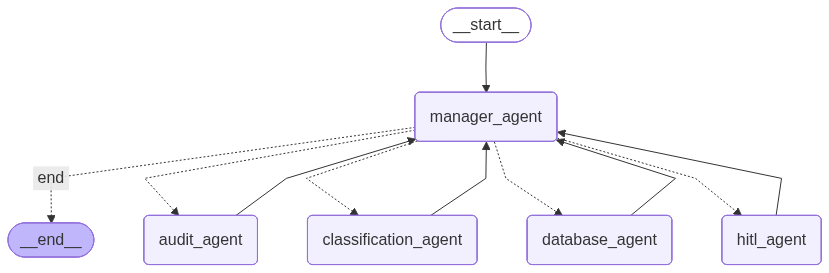

In [56]:
# Render and display the compiled workflow graph as a Mermaid PNG diagram.
from IPython.display import Image, display
display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

In [57]:
def stream_workflow(graph, file_path: str, config):
    """Run the graph and pretty-print each step as it streams."""
    initial_state: AgentState = {"file_path": file_path, "audit_log": []}
    seen_message_ids = set()

    for chunk in graph.stream(initial_state, config=config):
        for node_name, node_output in chunk.items():
            print(f"\n┌─ [{node_name.upper()}]")

            file_name = node_output.get("file_name")
            step      = node_output.get("workflow_step")
            cls       = node_output.get("classification")
            score     = node_output.get("confidence_score")
            details   = node_output.get("extraction_details")
            nxt       = node_output.get("next_agent")
            log       = node_output.get("audit_log", [])
            msgs      = node_output.get("messages", [])
            final     = node_output.get("final_message", [])

            if file_name : print(f"│  File Name          : {file_name}")
            if step      : print(f"│  Step               : {step}")
            if cls       : print(f"│  Classification     : {cls}")
            if nxt is not None: print(f"│  Routing           → : {nxt}")
            if score     : print(f"│  Confidence Score   : {score}")

            if msgs:
                for msg in msgs:
                    msg_id = getattr(msg, "id", None)
                    if msg_id and msg_id in seen_message_ids:
                        continue
                    if msg_id:
                        seen_message_ids.add(msg_id)
                    if hasattr(msg, "tool_calls") and msg.tool_calls:
                        for tool in msg.tool_calls:
                            print(f"│  Tool Call → {tool['name']}")
                            print(f"│  Args      → {tool['args']}")
                    if msg.__class__.__name__ == "ToolMessage":
                        print(f"│  Tool Result (first 50 chars): {msg.content[:50]}")

            if final   : print(f"│  Final Message      : {final}")
            if details : print(f"│  Extraction Details : {details}")
            if log     : print(f"│  Audit              : {log[-1]}")
            print(f"└{'─' * 50}")
            sys.stdout.flush()

    print("\n" + "=" * 60)
    print("  WORKFLOW COMPLETE")
    print("=" * 60)

Upload the inputdocs folder with files to be processed

In [33]:
# Create the inputdocs folder where PDF documents to be processed should be uploaded.
import os

folder_path = "/content/inputdocs"
os.makedirs(folder_path, exist_ok=True)

print("Folder created:", folder_path)

Folder created: /content/inputdocs


Execute the below code to process the documents and provide human decision for pending reviews to complete the transactions

In [80]:
# Iterate over all PDFs in the inputdocs folder and run the full multi-agent workflow on each.
import uuid

folder = "/content/inputdocs"

for file in os.listdir(folder):
    if ".pdf" not in file:
        continue
    config = {"configurable": {"thread_id": file + "_" + str(uuid.uuid4())}}
    stream_workflow(react_graph, f"{folder}/{file}", config)



┌─ [MANAGER_AGENT]
│  Step               : manager_routing
│  Routing           → : classification_agent
│  Audit              : 2026-03-23 13:05:13 | Manager Agent | Routing → classification_agent | classification is missing or null
└──────────────────────────────────────────────────

┌─ [CLASSIFICATION_AGENT]
│  File Name          : 07_software_license_violation.pdf
│  Step               : classified
│  Classification     : Cease
│  Confidence Score   : 98%
│  Tool Call → extract_pdf_text
│  Args      → {'file_path': '/content/inputdocs/07_software_license_violation.pdf'}
│  Tool Result (first 50 chars): CEASE AND DESIST LETTER
Michael Brennan, Esq.
Gene
│  Extraction Details : {'Sender': 'Michael Brennan, Esq., Forge Software Inc.', 'Recipient': 'Ms. Claire Dubois, Apex Consulting Group LLC', 'Violation Type': 'Software license violation (unauthorized deployment and sublicensing of ForgeDB Enterprise)', 'Demanded Action': 'Decommission excess installations, terminate sublicenses, p

To view the data inserted from the capstone database

In [84]:
# Query and display all records from the document_details database table as a DataFrame.
import pandas as pd

con = sqlite3.connect(DB_PATH)
df  = pd.read_sql("SELECT * FROM document_details ORDER BY created_at", con)
con.close()
df

,id,file_name,date_received,classification,confidence_score,human_decision,reason,extraction_details,created_at
0,1,07_software_license_violation.pdf,01-28-2026,Cease,98,None,Document explicitly contains 'CEASE AND DESIST...,"{""Sender"": ""Michael Brennan, Esq., Forge Softw...",2026-03-23 13:05:19
1,2,bw_doc_1.pdf,10-11-2025,Irrelevant,5%,None,The document is an informational notice about ...,None,2026-03-23 13:05:41
2,3,LOA8.pdf,01-26-2024,Cease,95%,None,The document explicitly contains a 'cease and ...,"{""Sender"":""Cordoba Legal Group, LLC"",""Recipien...",2026-03-23 13:06:31
3,4,bw_doc_3.pdf,10-11-2025,Irrelevant,5%,None,The document is a routine request for document...,null,2026-03-23 13:07:02
4,5,06_harassment_workplace.pdf,03-12-2026,Cease,95,None,The document explicitly demands cessation of w...,"{""Sender"":""Linda Fujimoto"",""Recipient"":""Mr. Th...",2026-03-23 13:07:41
5,6,notice_5.pdf,10-10-2025,Irrelevant,50,yes,The document requests review of outreach activ...,None,2026-03-23 13:08:27
6,7,LOA6.pdf,02-14-2023,Cease,95,None,Document explicitly demands recipient cease al...,"{""Sender"":""Five Lakes Law Group PLLC"",""Recipie...",2026-03-23 13:09:06
7,8,04_defamation_online_review.pdf,03-03-2026,Cease,95%,None,Document explicitly demands cessation of defam...,"{""Sender"":""Dr. Samantha Ellis, Ellis Integrati...",2026-03-23 13:09:45
8,9,notice_4.pdf,10-10-2025,Cease,65,yes,The document requests the recipient cease non-...,None,2026-03-23 13:10:44
9,10,10_breach_of_contract_nda.pdf,02-12-2026,Cease,95,None,Document explicitly demands cessation of unaut...,"{""Sender"":""Whitfield & Chang LLP"",""Recipient"":...",2026-03-23 13:11:14
